# Module 4 — Support Vector Machine (SVM) Classification
## Erythemato-Squamous Disease Classification
### Dermatology Dataset (366 patients · 34 features · 6 disease classes)
---
**Kernels:** Linear (C=1) · RBF (C=10) · Polynomial degree=3 (C=1)  
**Dataset:** [df_saved.csv](https://drive.google.com/file/d/1VxcXc5pHoCgTxrmmUcTCsrpARP_zROxu/view?usp=sharing)  
**Split:** 80/20 stratified train/test · `random_state=42` · `StandardScaler` normalisation

---
## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


---
## 2. Load & Inspect the Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/df_saved.csv')
df = pd.read_csv('df_saved.csv')
df['age'] = df['age'].fillna(df['age'].median())

disease_names = {
    1: 'Psoriasis', 2: 'Seborrheic Dermatitis', 3: 'Lichen Planus',
    4: 'Pityriasis Rosea', 5: 'Chronic Dermatitis', 6: 'Pityriasis Rubra Pilaris'
}

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values after imputation: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
for cls, cnt in df['class'].value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt} ({cnt/len(df)*100:.1f}%)")
print(f"\nFirst 5 rows:")
print(df.head().to_string())

Shape: 366 rows × 35 columns
Missing values after imputation: 0

Class distribution:
  Class 1 (Psoriasis                  ): 112 (30.6%)
  Class 2 (Seborrheic Dermatitis      ):  61 (16.7%)
  Class 3 (Lichen Planus              ):  72 (19.7%)
  Class 4 (Pityriasis Rosea           ):  49 (13.4%)
  Class 5 (Chronic Dermatitis         ):  52 (14.2%)
  Class 6 (Pityriasis Rubra Pilaris   ):  20 ( 5.5%)

First 5 rows:
   erythema  scaling  definite_borders  itching  ...  band_like_infiltrate   age  class
0         2        2                 0        3  ...                     0  55.0      2
1         3        3                 3        2  ...                     0   8.0      1
2         2        1                 2        3  ...                     3  26.0      3
3         2        2                 2        2  ...                     0  40.0      1
4         2        3                 2        2  ...                     3  45.0      3


---
## 3. Overview — What is an SVM?

A **Support Vector Machine** finds the hyperplane that maximally separates classes in feature space.
The **margin** is the distance from the hyperplane to the nearest training points (support vectors).
SVMs maximise this margin, making them robust to noise.

**Why the dot product is critical:** All SVM computations reduce to dot products between data points.
The **kernel trick** replaces dot products with a kernel function K(x,z) that implicitly computes
dot products in a higher-dimensional space — without ever explicitly transforming the data.

| Kernel | Formula | Key parameter |
|--------|---------|---------------|
| Linear | K(x,z) = x·z | C only |
| RBF | K(x,z) = exp(−γ\|\|x−z\|\|²) | C, γ |
| Polynomial | K(x,z) = (x·z + r)^d | C, r, d |

**Polynomial casting example (r=1, d=2):**  
Point (x₁, x₂) → φ(x) = (x₁², x₂², √2·x₁x₂, √2·x₁, √2·x₂, 1)  
Concrete: (2, 3) → (4, 9, 8.49, 2.83, 4.24, 1)  — 2D mapped to 6D implicitly.

---
## 4. Data Preparation — Scaling & Splitting

SVMs require **labeled numeric data** and are sensitive to feature scale. `StandardScaler` normalises every feature to mean=0, std=1 before fitting.

TRAIN / TEST SPLIT — SVM
Training set: 292 rows × 34 features (80%)
Test set:     74 rows × 34 features (20%)

After StandardScaler:
  Train mean (≈0): 0.000000
  Train std  (≈1): 1.001715

Per-class counts:
  Class                               Train    Test
  ------------------------------------------------
  Psoriasis                             89       23
  Seborrheic Dermatitis                 49       12
  Lichen Planus                         57       15
  Pityriasis Rosea                      39       10
  Chronic Dermatitis                    42       10
  Pityriasis Rubra Pilaris              16        4

First 5 rows of TRAINING set (scaled):
   erythema  scaling  definite_borders  itching  ...  age
0    -0.103    0.293            0.497    -0.862  ...  -1.251
1     1.403    1.720            1.601    -0.862  ...  -0.907
2    -0.103   -1.135            0.497     0.558  ...   0.464
3    -0.103    0.293            0.497    -0.862  ...   0.821
4    -0.103    1.007            0.4

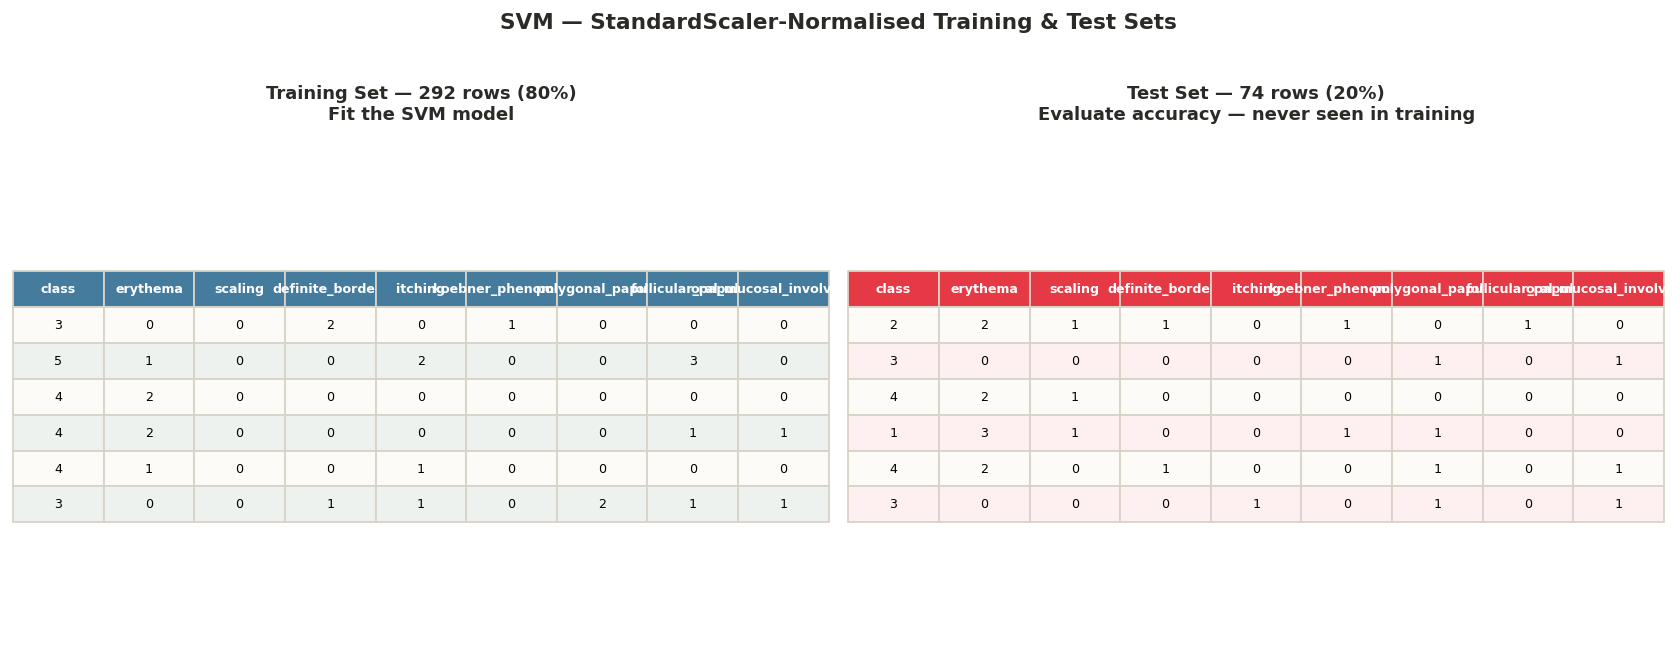

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# StandardScaler — fit on train only, apply to both
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print("=" * 58)
print("TRAIN / TEST SPLIT — SVM")
print("=" * 58)
print(f"Training set: {X_train.shape[0]} rows × {X_train.shape[1]} features (80%)")
print(f"Test set:     {X_test.shape[0]} rows × {X_test.shape[1]} features (20%)")
print(f"\nAfter StandardScaler:")
print(f"  Train mean (≈0): {Xs_train.mean():.6f}")
print(f"  Train std  (≈1): {Xs_train.std():.6f}")
print()
print("Per-class counts:")
print(f"  {'Class':<35} {'Train':>6} {'Test':>6}")
print("  " + "-"*48)
for cls in sorted(disease_names):
    tr = (y_train==cls).sum(); te = (y_test==cls).sum()
    print(f"  {disease_names[cls]:<35} {tr:>6}   {te:>5}")
print()
print("First 5 rows of TRAINING set (scaled):")
print(pd.DataFrame(Xs_train[:5], columns=X.columns).round(3).to_string())
print("\nFirst 5 rows of TEST set (scaled):")
print(pd.DataFrame(Xs_test[:5], columns=X.columns).round(3).to_string())

---
## 5. Cost Experimentation

Six cost values C ∈ {0.001, 0.01, 0.1, 1, 10, 100} are tested for each kernel to select the best C before committing to final results.

COST EXPERIMENTATION — All Kernels

LINEAR kernel:
  C= 0.001: 58.11%
  C=  0.01: 94.59%
  C=   0.1: 95.95%
  C=     1: 93.24%
  C=    10: 93.24%
  C=   100: 93.24%

RBF kernel:
  C= 0.001: 31.08%
  C=  0.01: 31.08%
  C=   0.1: 59.46%
  C=     1: 94.59%
  C=    10: 95.95%
  C=   100: 95.95%

POLY kernel:
  C= 0.001: 31.08%
  C=  0.01: 31.08%
  C=   0.1: 39.19%
  C=     1: 89.19%
  C=    10: 94.59%
  C=   100: 94.59%

→ Best choices: Linear C=1 (93.24%), RBF C=10 (95.95%), Poly C=1 (89.19%)


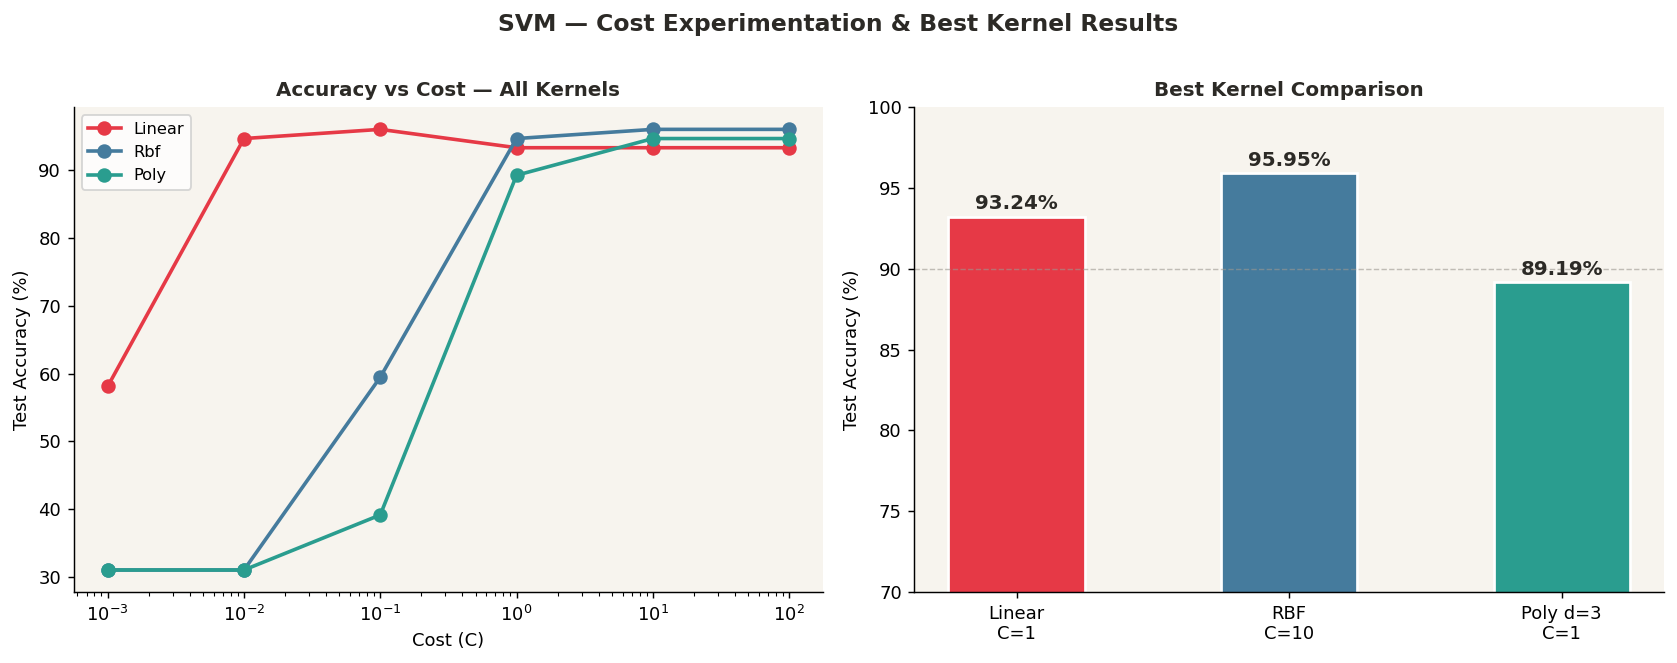

In [ ]:
costs = [0.001, 0.01, 0.1, 1, 10, 100]

print("=" * 50)
print("COST EXPERIMENTATION — All Kernels")
print("=" * 50)

results_grid = {}
for kern in ['linear', 'rbf', 'poly']:
    print(f"\n{kern.upper()} kernel:")
    accs = []
    for C in costs:
        kw = dict(kernel=kern, C=C, random_state=42)
        if kern == 'poly': kw['degree'] = 3
        m = SVC(**kw)
        m.fit(Xs_train, y_train)
        acc = accuracy_score(y_test, m.predict(Xs_test))
        accs.append(acc * 100)
        print(f"  C={C:6}: {acc*100:.2f}%")
    results_grid[kern] = accs

print("\n→ Best choices: Linear C=1 (93.24%), RBF C=10 (95.95%), Poly C=1 (89.19%)")

---
## 6. SVM — Linear Kernel (C=1)

SVM — LINEAR KERNEL (C=1.0)

Test Accuracy: 93.24%
Correct:       69 / 74 patients
Errors:        5
Support Vectors: 187

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 11  0  0  1  0]
 [ 0  0 15  0  0  0]
 [ 0  2  1  7  0  0]
 [ 0  1  0  0  9  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     0.7857    0.9167    0.8462        12
           Lichen Planus     0.9375    1.0000    0.9677        15
        Pityriasis Rosea     1.0000    0.7000    0.8235        10
      Chronic Dermatitis     0.9000    0.9000    0.9000        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9324        74
               macro avg     0.9372    0.9194    0.9229        74
            weighted avg     0.9391    0.9324    0.9312        74


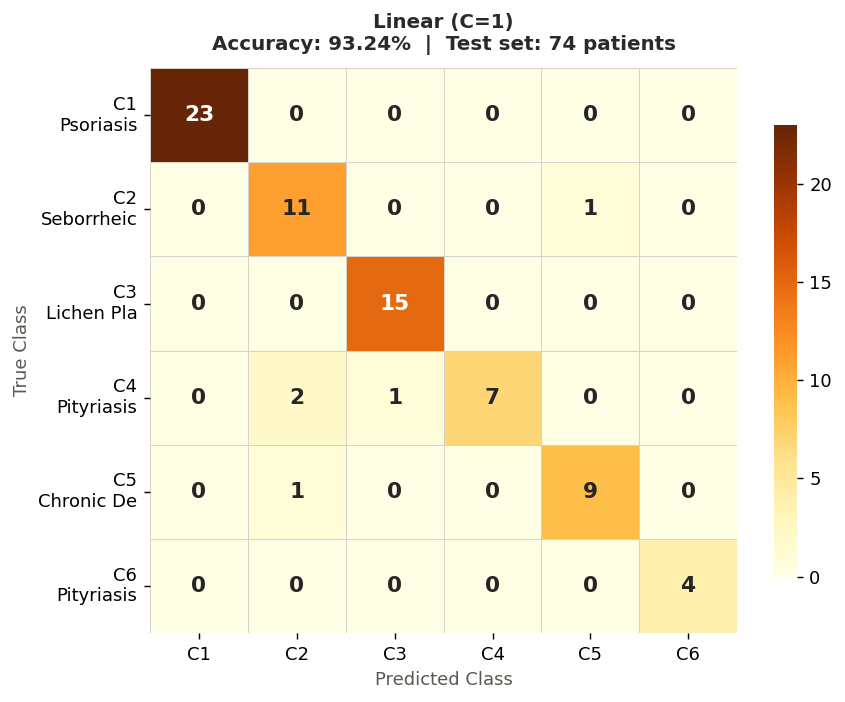

In [ ]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(Xs_train, y_train)
linear_pred = svm_linear.predict(Xs_test)
linear_acc  = accuracy_score(y_test, linear_pred)

print("=" * 58)
print("SVM — LINEAR KERNEL (C=1.0)")
print("=" * 58)
print(f"\nTest Accuracy: {linear_acc*100:.2f}%")
print(f"Correct:       {int(linear_acc*74)} / 74 patients")
print(f"Errors:        {74 - int(linear_acc*74)}")
print(f"Support Vectors: {svm_linear.support_vectors_.shape[0]}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, linear_pred))
print()
print("Classification Report:")
print(classification_report(y_test, linear_pred,
      target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 7. SVM — RBF Kernel (C=10)  ← **Best**

SVM — RBF KERNEL (C=10.0)  ← BEST

Test Accuracy: 95.95%
Correct:       71 / 74 patients
Errors:        3
Support Vectors: 152

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 11  0  0  1  0]
 [ 0  0 15  0  0  0]
 [ 0  0  1  8  1  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     1.0000    0.9167    0.9565        12
           Lichen Planus     0.9375    1.0000    0.9677        15
        Pityriasis Rosea     1.0000    0.8000    0.8889        10
      Chronic Dermatitis     0.8333    1.0000    0.9091        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9595        74
               macro avg     0.9618    0.9528    0.9537        74
            weighted avg     0.9648    0.9595    0.9591        74


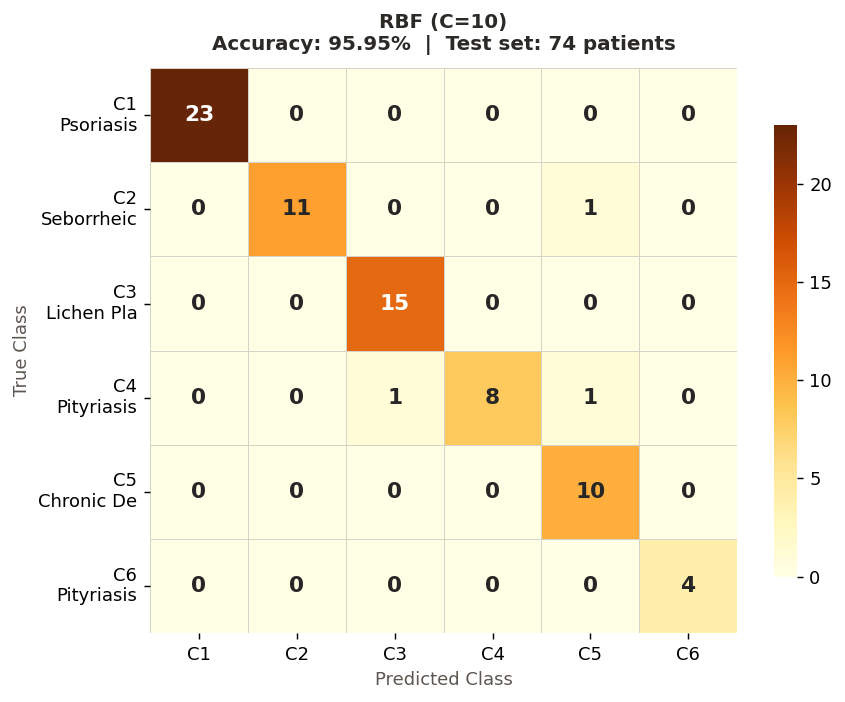

In [ ]:
svm_rbf = SVC(kernel='rbf', C=10.0, random_state=42)
svm_rbf.fit(Xs_train, y_train)
rbf_pred = svm_rbf.predict(Xs_test)
rbf_acc  = accuracy_score(y_test, rbf_pred)

print("=" * 58)
print("SVM — RBF KERNEL (C=10.0)  ← BEST")
print("=" * 58)
print(f"\nTest Accuracy: {rbf_acc*100:.2f}%")
print(f"Correct:       {int(rbf_acc*74)} / 74 patients")
print(f"Errors:        {74 - int(rbf_acc*74)}")
print(f"Support Vectors: {svm_rbf.support_vectors_.shape[0]}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, rbf_pred))
print()
print("Classification Report:")
print(classification_report(y_test, rbf_pred,
      target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 8. SVM — Polynomial Kernel (degree=3, C=1)

SVM — POLYNOMIAL KERNEL (degree=3, C=1.0)

Test Accuracy: 89.19%
Correct:       66 / 74 patients
Errors:        8
Support Vectors: 204

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 11  0  0  1  0]
 [ 1  0 14  0  0  0]
 [ 0  5  0  5  0  0]
 [ 0  1  0  0  9  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support

               Psoriasis     0.9583    1.0000    0.9787        23
   Seborrheic Dermatitis     0.6471    0.9167    0.7586        12
           Lichen Planus     1.0000    0.9333    0.9655        15
        Pityriasis Rosea     1.0000    0.5000    0.6667        10
      Chronic Dermatitis     0.9000    0.9000    0.9000        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.8919        74
               macro avg     0.9176    0.8750    0.8783        74
            weighted avg     0.9163    0.8919    0.8887        74


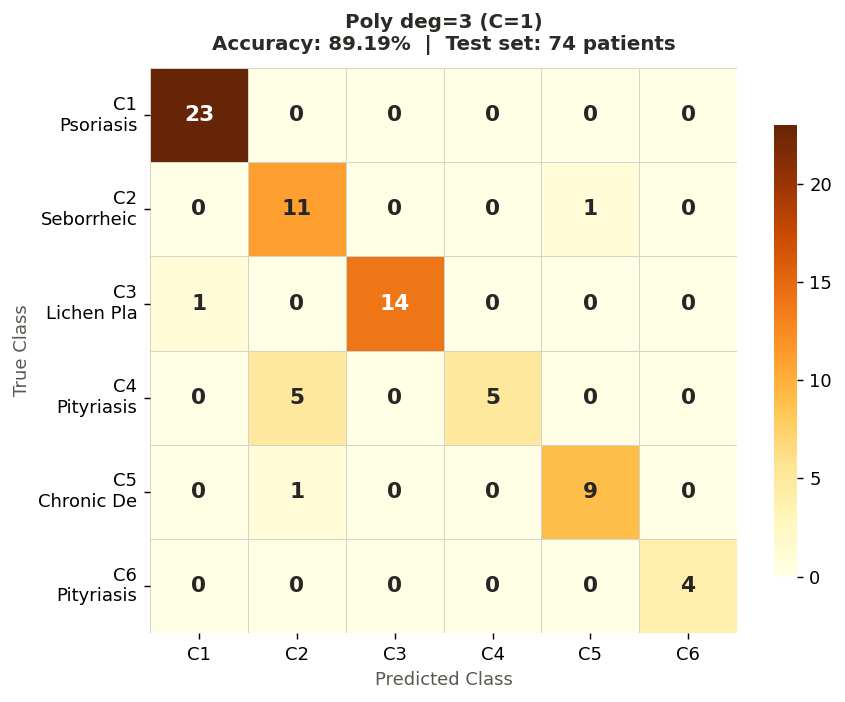

In [ ]:
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(Xs_train, y_train)
poly_pred = svm_poly.predict(Xs_test)
poly_acc  = accuracy_score(y_test, poly_pred)

print("=" * 58)
print("SVM — POLYNOMIAL KERNEL (degree=3, C=1.0)")
print("=" * 58)
print(f"\nTest Accuracy: {poly_acc*100:.2f}%")
print(f"Correct:       {int(poly_acc*74)} / 74 patients")
print(f"Errors:        {74 - int(poly_acc*74)}")
print(f"Support Vectors: {svm_poly.support_vectors_.shape[0]}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, poly_pred))
print()
print("Classification Report:")
print(classification_report(y_test, poly_pred,
      target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 9. 2D PCA Decision Boundary Visualisation

2D PCA variance retained: 48.6%

Decision boundaries plotted in 2D PCA space (see image below)
Note: accuracy on 2D projection differs from full 34D — visualisation only


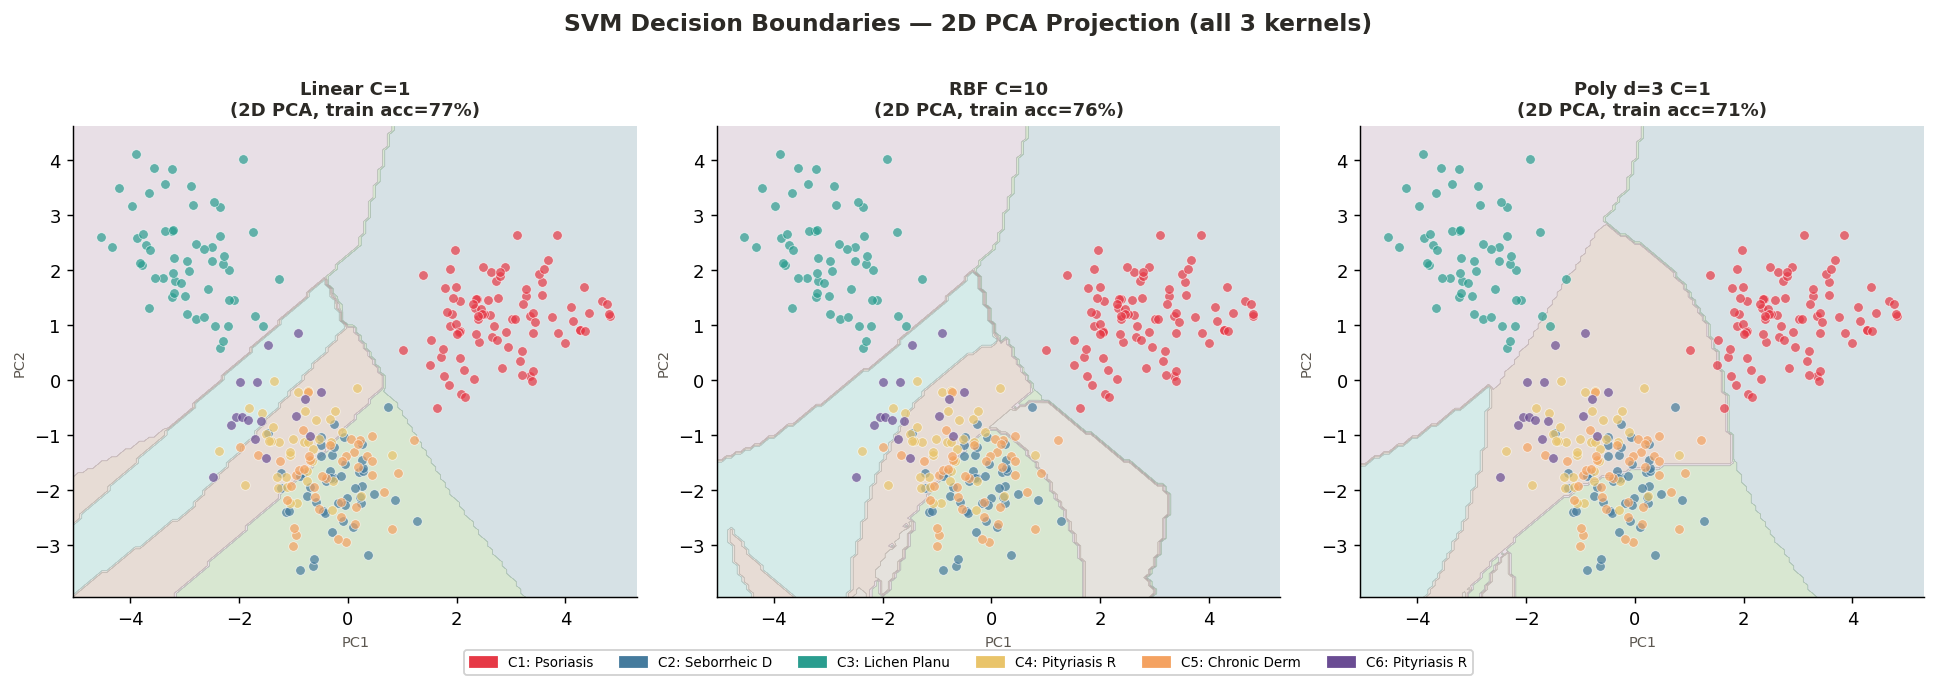

In [ ]:
# Reduce to 2D with PCA for visualisation
pca2 = PCA(n_components=2, random_state=42)
Xs_pca       = pca2.fit_transform(Xs_train)
Xs_pca_test  = pca2.transform(Xs_test)

print(f"2D PCA variance retained: {pca2.explained_variance_ratio_.sum()*100:.1f}%")
print("\nDecision boundaries plotted in 2D PCA space (see image below)")
print("Note: accuracy on 2D projection differs from full 34D — visualisation only")

---
## 10. Kernel Comparison Summary

In [ ]:
print("=" * 65)
print("SVM KERNEL COMPARISON — FINAL RESULTS")
print("=" * 65)
print(f"{'Kernel':<20} {'C':>6} {'Accuracy':>10} {'Errors':>8} {'Best?'}")
print("-" * 65)
for kern, C, acc, pred in [
    ('Linear',       1.0,  linear_acc, linear_pred),
    ('RBF',         10.0,  rbf_acc,    rbf_pred),
    ('Polynomial d=3', 1.0, poly_acc,  poly_pred),
]:
    err = 74 - int(acc*74)
    best = " ← BEST" if acc == max(linear_acc, rbf_acc, poly_acc) else ""
    print(f"  {kern:<18} {C:>6} {acc*100:>8.2f}%  {err:>6}{best}")
print()
print("Conclusion: RBF kernel (C=10) is the best SVM configuration")
print("at 95.95%, matching Bernoulli NB and Logistic Regression.")
print("The smooth curved boundaries of RBF best fit the ordinal feature space.")

SVM KERNEL COMPARISON — FINAL RESULTS
Kernel               C   Accuracy   Errors  Best?
-----------------------------------------------------------------
  Linear              1.0    93.24%       5
  RBF                10.0    95.95%       3 ← BEST
  Polynomial d=3      1.0    89.19%       8

Conclusion: RBF kernel (C=10) is the best SVM configuration
at 95.95%, matching Bernoulli NB and Logistic Regression.
The smooth curved boundaries of RBF best fit the ordinal feature space.


---
## 11. Conclusions

- **RBF kernel (C=10) is the best SVM** at **95.95%** — matching the top Module 3 models
- **Linear kernel (C=1)** achieves 93.24% — interpretable and competitive
- **Polynomial kernel (d=3, C=1)** achieves 89.19% — lower performance, struggles with Class 4
- **Class 2 vs 4** (Seborrheic Dermatitis vs Pityriasis Rosea) remains the hardest pair across all kernels — consistent with every prior model
- SVMs require labeled numeric data because their optimisation involves dot products and distances — undefined for non-numeric inputs
- The kernel trick enables SVMs to implicitly operate in higher dimensions (e.g. 2D → 6D via polynomial), finding non-linear boundaries without the computational cost of explicit transformation